# ES Futures Regression Analysis — Same Approach as Lab 2

This notebook applies the **same linear-regression workflow** from your `Lab_2.ipynb` to **Yahoo Finance `ES=F` historical data**.

## Outline
- 1. Data loading and feature engineering
- 2. Simple Linear Regression
- 3. Multiple Linear Regression
- 4. Interaction Terms
- 5. Non-linear Transformations of Predictors
- 6. Qualitative Predictors
- 7. Optimization Methods for Linear Regression

## Modeling idea
Because this is a market dataset, we first create a supervised-learning target:
- **Target (`target_next_return`)** = next-day percentage return of the ES futures close

And we create predictors such as:
- lagged returns
- intraday range
- open-close move
- rolling volatility
- rolling moving-average gap
- volume change
- weekday category

That keeps the notebook close to the original lab, while making it appropriate for time-series market data.


In [2]:
# If needed, uncomment these lines the first time you run the notebook
# !pip install yfinance statsmodels seaborn scikit-learn

%matplotlib inline

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from numpy.linalg import inv

pd.set_option('display.precision', 6)
pd.set_option('display.max_rows', 10)
pd.set_option('display.float_format', '{:,.6f}'.format)
sns.set_theme(style='whitegrid')


## 1. Load Yahoo Finance ES=F data

This cell downloads daily historical data for the Yahoo Finance ticker `ES=F`.
You can change the date range if you want a longer or shorter sample.


In [5]:
import yfinance as yf

symbol = 'ES=F'
start_date = '2018-01-01'
end_date = None

raw = yf.download(symbol, start=start_date, end=end_date, interval='1d', auto_adjust=False, progress=False)
raw.head()


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,ES=F,ES=F,ES=F,ES=F,ES=F,ES=F
Date,,,,,,
2018-01-02,"2,693.000000","2,693.000000","2,696.000000","2,674.500000","2,675.250000",996265
2018-01-03,"2,711.000000","2,711.000000","2,714.250000","2,692.250000","2,693.750000",1114548
2018-01-04,"2,723.750000","2,723.750000","2,729.000000","2,708.500000","2,710.250000",1166017
2018-01-05,"2,742.500000","2,742.500000","2,743.250000","2,723.750000","2,725.000000",1136500
2018-01-08,"2,746.750000","2,746.750000","2,748.500000","2,736.500000","2,741.750000",903544


In [7]:
# Clean columns in case yfinance returns a MultiIndex
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

es = raw.copy().reset_index()
es.columns = [str(c).replace(' ', '_') for c in es.columns]
es = es.sort_values('Date').reset_index(drop=True)

es.tail()


,Date,Adj_Close,Close,High,Low,Open,Volume
2064,2026-03-17,"6,721.750000","6,721.750000","6,757.500000","6,665.250000","6,700.000000",834934
2065,2026-03-18,"6,626.000000","6,626.000000","6,762.250000","6,604.000000","6,722.500000",501911
2066,2026-03-19,"6,609.250000","6,609.250000","6,644.500000","6,561.750000","6,622.000000",450179
2067,2026-03-20,"6,594.629883","6,594.629883","6,635.000000","6,558.000000","6,622.750000",450179
2068,2026-03-23,"6,656.750000","6,656.750000","6,748.000000","6,483.500000","6,510.000000",1724901


## 1.1 Feature engineering

We create a regression-style dataset where today's features try to explain **tomorrow's return**.


In [12]:
df = es.copy().reset_index()

# Features
df['return_1d'] = df['Close'].pct_change()
df['lag1_return'] = df['return_1d'].shift(1)
df['lag2_return'] = df['return_1d'].shift(2)
df['lag3_return'] = df['return_1d'].shift(3)

df['range_pct'] = (df['High'] - df['Low']) / df['Close']
df['oc_change_pct'] = (df['Close'] - df['Open']) / df['Open']

df['volatility_5'] = df['return_1d'].rolling(5).std()
df['volatility_10'] = df['return_1d'].rolling(10).std()

df['sma_5'] = df['Close'].rolling(5).mean()
df['sma_10'] = df['Close'].rolling(10).mean()
df['sma_gap_pct'] = (df['sma_5'] - df['sma_10']) / df['sma_10']

df['volume_change'] = df['Volume'].pct_change()

# Qualitative
df['weekday'] = pd.to_datetime(df['Date']).dt.day_name()

# Target
df['target_next_return'] = df['Close'].pct_change().shift(-1)

# Final dataset
model_df = df[[
    'Date', 'Open', 'High', 'Low', 'Close', 'Volume',
    'lag1_return', 'lag2_return', 'lag3_return',
    'range_pct', 'oc_change_pct', 'volatility_5', 'volatility_10',
    'sma_gap_pct', 'volume_change', 'weekday', 'target_next_return'
]].dropna().reset_index(drop=True)

In [14]:
model_df.describe().T


,count,mean,min,25%,50%,75%,max,std
Date,2057,2022-02-15 21:48:23.451628800,2018-01-17 00:00:00,2020-02-03 00:00:00,2022-02-15 00:00:00,2024-03-04 00:00:00,2026-03-20 00:00:00,NaN
Open,"2,057.000000","4,231.621779","2,220.250000","3,036.000000","4,132.250000","5,057.000000","7,021.500000","1,245.024306"
High,"2,057.000000","4,262.065372","2,386.000000","3,065.500000","4,161.750000","5,113.000000","7,043.000000","1,248.889493"
Low,"2,057.000000","4,199.351215","2,174.000000","3,005.000000","4,099.000000","5,036.250000","6,977.250000","1,239.626276"
Close,"2,057.000000","4,233.483053","2,220.500000","3,036.250000","4,130.500000","5,080.250000","7,016.500000","1,244.754181"
...,...,...,...,...,...,...,...,...
volatility_5,"2,057.000000",0.009729,0.000833,0.005110,0.007823,0.011798,0.087016,0.007981
volatility_10,"2,057.000000",0.010087,0.002271,0.005841,0.008365,0.012021,0.073800,0.007301
sma_gap_pct,"2,057.000000",0.001074,-0.068693,-0.003557,0.002292,0.006969,0.043501,0.010066
volume_change,"2,057.000000",inf,-1.000000,-0.176623,-0.022921,0.177363,inf,NaN


# 2. Simple Linear Regression

We start with the closest analogue to the original notebook:

- **X** = previous day's return (`lag1_return`)
- **y** = next day's return (`target_next_return`)


### 2.1 Scatter plot with matplotlib

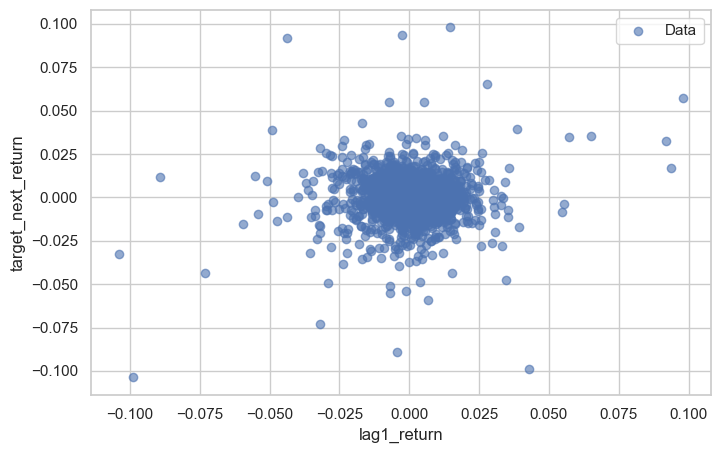

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(model_df['lag1_return'].values, model_df['target_next_return'].values, alpha=0.6, label='Data')
ax.set_xlabel('lag1_return')
ax.set_ylabel('target_next_return')
ax.legend();
plt.show()


### 2.2 Scatter plot using pandas

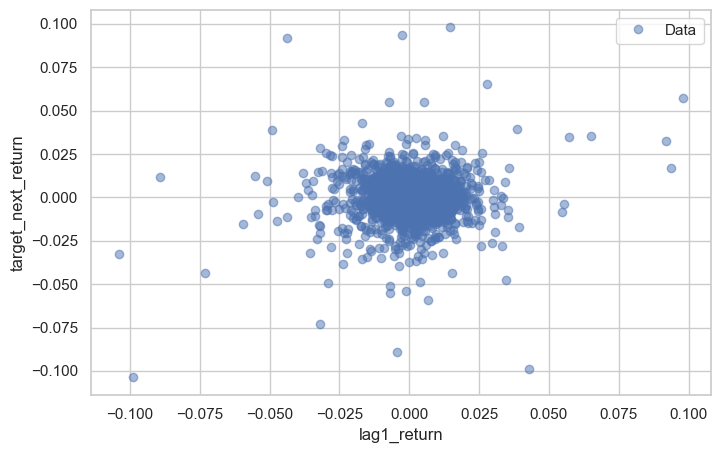

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))
model_df.plot(x='lag1_return', y='target_next_return', style='o', alpha=0.5, ax=ax)
ax.set_ylabel('target_next_return')
ax.legend(['Data']);
plt.show()


### 2.3 Simple Linear Regression using scikit-learn

In [25]:
LR_sklearn = LinearRegression(fit_intercept=True)

X_train = model_df['lag1_return'].values.reshape(-1, 1)
y_train = model_df['target_next_return'].values

LR_sklearn.fit(X_train, y_train)
print('Intercept:', LR_sklearn.intercept_)
print('Slope:', LR_sklearn.coef_[0])


Intercept: 0.0004612550849494084
Slope: 0.07257771349248514


### 2.4 Model performance

In [28]:
y_pred = LR_sklearn.predict(X_train)

print('R^2: {:.6f}'.format(r2_score(y_train, y_pred)))
print('MSE: {:.8f}'.format(mean_squared_error(y_train, y_pred)))


R^2: 0.005266
MSE: 0.00015041


### 2.5 Draw the regression line

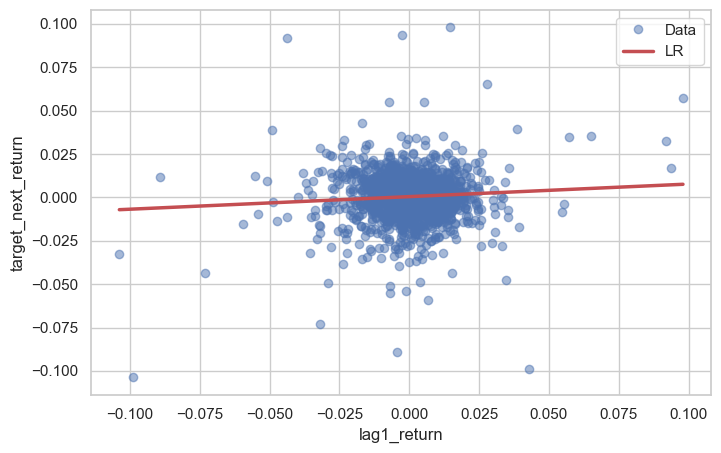

In [31]:
fig, ax = plt.subplots(figsize=(8, 5))
model_df.plot(x='lag1_return', y='target_next_return', style='o', alpha=0.5, ax=ax)
xs = np.linspace(model_df['lag1_return'].min(), model_df['lag1_return'].max(), 200).reshape(-1, 1)
ys = LR_sklearn.predict(xs)
ax.plot(xs, ys, 'r', linewidth=2.5)
ax.set_ylabel('target_next_return')
ax.legend(['Data', 'LR'])
plt.show()


### 2.6 Simple Linear Regression using statsmodels

In [34]:
ols_sm = sm.OLS(y_train, sm.add_constant(X_train))
ols_sm_results = ols_sm.fit()
print(ols_sm_results.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     10.88
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           0.000989
Time:                        03:45:12   Log-Likelihood:                 6134.2
No. Observations:                2057   AIC:                        -1.226e+04
Df Residuals:                    2055   BIC:                        -1.225e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.000      1.704      0.0

### 2.7 Draw the regression line with Seaborn

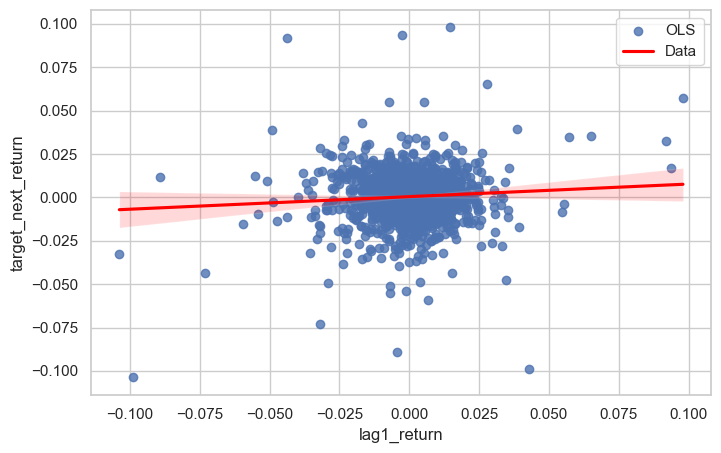

In [37]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(x='lag1_return', y='target_next_return', data=model_df, line_kws={'color': 'red'}, ci=95, ax=ax)
ax.legend(['OLS', 'Data'])
plt.show()


# 3. Multiple Linear Regression

Now we extend the model using several engineered predictors.


In [45]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

# -----------------------------
# 1. Copy and reset index
# -----------------------------
df = es.copy().reset_index()

# -----------------------------
# 2. Feature engineering
# -----------------------------
df['return_1d'] = df['Close'].pct_change()
df['lag1_return'] = df['return_1d'].shift(1)
df['lag2_return'] = df['return_1d'].shift(2)
df['lag3_return'] = df['return_1d'].shift(3)

df['range_pct'] = (df['High'] - df['Low']) / df['Close']
df['oc_change_pct'] = (df['Close'] - df['Open']) / df['Open']

df['volatility_5'] = df['return_1d'].rolling(5).std()
df['volatility_10'] = df['return_1d'].rolling(10).std()

df['sma_5'] = df['Close'].rolling(5).mean()
df['sma_10'] = df['Close'].rolling(10).mean()
df['sma_gap_pct'] = (df['sma_5'] - df['sma_10']) / df['sma_10']

df['volume_change'] = df['Volume'].pct_change()

df['weekday'] = pd.to_datetime(df['Date']).dt.day_name()

# next-day return target
df['target_next_return'] = df['Close'].pct_change().shift(-1)

# -----------------------------
# 3. Keep needed columns
# -----------------------------
model_df = df[[
    'Date', 'Open', 'High', 'Low', 'Close', 'Volume',
    'lag1_return', 'lag2_return', 'lag3_return',
    'range_pct', 'oc_change_pct', 'volatility_5', 'volatility_10',
    'sma_gap_pct', 'volume_change', 'weekday', 'target_next_return'
]].copy()

# -----------------------------
# 4. Replace inf with NaN, then drop missing rows
# -----------------------------
model_df = model_df.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

# -----------------------------
# 5. Multiple regression
# -----------------------------
xcols = [
    'lag1_return', 'lag2_return', 'lag3_return',
    'range_pct', 'oc_change_pct', 'volatility_5',
    'sma_gap_pct', 'volume_change'
]

X_multi = model_df[xcols]
y_multi = model_df['target_next_return']

ols_sklearn_multi = LinearRegression()
ols_sklearn_multi.fit(X_multi, y_multi)

print('Intercept:', ols_sklearn_multi.intercept_)
coef_table = pd.Series(ols_sklearn_multi.coef_, index=xcols, name='coefficient')
print(coef_table)

Intercept: 0.00031056916810870134
lag1_return      0.073704
lag2_return      0.004284
lag3_return     -0.074505
range_pct        0.118230
oc_change_pct   -0.126515
volatility_5    -0.155998
sma_gap_pct     -0.000030
volume_change   -0.000691
Name: coefficient, dtype: float64


In [47]:
y_multi_pred = ols_sklearn_multi.predict(X_multi)
print('R^2: {:.6f}'.format(r2_score(y_multi, y_multi_pred)))
print('MSE: {:.8f}'.format(mean_squared_error(y_multi, y_multi_pred)))


R^2: 0.034052
MSE: 0.00014633


In [49]:
ols_sm_multi = sm.OLS(y_multi, sm.add_constant(X_multi))
ols_sm_multi_results = ols_sm_multi.fit()
print(ols_sm_multi_results.summary())


                            OLS Regression Results                            
Dep. Variable:     target_next_return   R-squared:                       0.034
Model:                            OLS   Adj. R-squared:                  0.030
Method:                 Least Squares   F-statistic:                     8.998
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           3.33e-12
Time:                        03:48:23   Log-Likelihood:                 6144.5
No. Observations:                2051   AIC:                        -1.227e+04
Df Residuals:                    2042   BIC:                        -1.222e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0003      0.001      0.605

# 4. Interaction Terms

A common market question is whether the effect of a lagged return changes when volatility changes.


In [53]:
interaction_model = smf.ols(
    formula='target_next_return ~ lag1_return * volatility_5 + range_pct + oc_change_pct',
    data=model_df
).fit()

print(interaction_model.summary())


                            OLS Regression Results                            
Dep. Variable:     target_next_return   R-squared:                       0.041
Model:                            OLS   Adj. R-squared:                  0.038
Method:                 Least Squares   F-statistic:                     17.31
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           8.15e-17
Time:                        03:48:27   Log-Likelihood:                 6151.5
No. Observations:                2051   AIC:                        -1.229e+04
Df Residuals:                    2045   BIC:                        -1.226e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

# 5. Non-linear Transformations of Predictors

### 5.1 2nd-order polynomial

In [57]:
poly2 = smf.ols(
    formula='target_next_return ~ lag1_return + np.power(lag1_return, 2)',
    data=model_df
).fit()

print(poly2.summary())


                            OLS Regression Results                            
Dep. Variable:     target_next_return   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     6.075
Date:                Tue, 24 Mar 2026   Prob (F-statistic):            0.00234
Time:                        03:48:29   Log-Likelihood:                 6115.1
No. Observations:                2051   AIC:                        -1.222e+04
Df Residuals:                    2048   BIC:                        -1.221e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

### 5.2 5th-order polynomial

In [60]:
poly5 = smf.ols(
    formula='target_next_return ~ lag1_return + np.power(lag1_return, 2) + np.power(lag1_return, 3) + np.power(lag1_return, 4) + np.power(lag1_return, 5)',
    data=model_df
).fit()

print(poly5.summary())


                            OLS Regression Results                            
Dep. Variable:     target_next_return   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.035
Method:                 Least Squares   F-statistic:                     15.99
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           1.73e-15
Time:                        03:48:30   Log-Likelihood:                 6148.4
No. Observations:                2051   AIC:                        -1.228e+04
Df Residuals:                    2045   BIC:                        -1.225e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

### 5.3 Compare polynomial fits visually

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(model_df['lag1_return'].values, model_df['target_next_return'].values, alpha=0.35, label='Data')
sns.regplot(x='lag1_return', y='target_next_return', data=model_df, order=1, scatter=False, label='Degree 1', ax=ax)
sns.regplot(x='lag1_return', y='target_next_return', data=model_df, order=2, scatter=False, label='Degree 2', ax=ax)
sns.regplot(x='lag1_return', y='target_next_return', data=model_df, order=3, scatter=False, label='Degree 3', ax=ax)
sns.regplot(x='lag1_return', y='target_next_return', data=model_df, order=5, scatter=False, label='Degree 5', ax=ax)
plt.legend()
plt.show()


# 6. Qualitative Predictors

We include **weekday** as a categorical variable to test whether average next-day return differs by trading day.


In [ ]:
qual_model = smf.ols(
    formula='target_next_return ~ lag1_return + range_pct + oc_change_pct + volatility_5 + C(weekday)',
    data=model_df
).fit()

print(qual_model.summary())


# 7. Optimization Methods for Linear Regression

We repeat the optimization part of the original lab on the simple 1-feature model.


### 7.1 Closed-form solution

In [ ]:
X_opt = model_df['lag1_return'].values
X_opt = sm.add_constant(X_opt)
y_opt = model_df['target_next_return'].values

beta_direct = inv(X_opt.T.dot(X_opt)).dot(X_opt.T).dot(y_opt)
print('Closed-form beta:', beta_direct)


### 7.2 Compare with statsmodels

In [ ]:
ols_check = sm.OLS(y_opt, X_opt).fit()
print(ols_check.params)
print(ols_check.summary())


### 7.3 Gradient Descent

In [ ]:
np.random.seed(42)

beta = np.random.rand(2)
alpha = 0.01
epochs = 5000
n = float(len(X_opt))

cost = []
for epoch in range(epochs):
    y_pred = np.dot(X_opt, beta)
    error = y_pred - y_opt
    dbeta = (1 / n) * np.dot(X_opt.T, error)
    beta = beta - alpha * dbeta
    J = (1 / n) * np.dot(error.T, error)
    cost.append(J)

print('Learned parameters through GD:', beta)
print('Closed-form parameters:', beta_direct)

plt.figure(figsize=(8, 5))
plt.plot(np.arange(epochs), cost)
plt.title('Gradient Descent Learning Curve')
plt.xlabel('Epoch')
plt.ylabel('J(beta)')
plt.show()


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_opt[:, 1], y_opt, alpha=0.5)
xs = np.linspace(X_opt[:, 1].min(), X_opt[:, 1].max(), 200)
xs2 = sm.add_constant(xs)
ys = np.dot(xs2, beta)
ax.plot(xs, ys, 'r', linewidth=2.5)
ax.set_xlabel('lag1_return')
ax.set_ylabel('target_next_return')
ax.legend(['GD fit', 'Data'])
plt.show()


### 7.4 Stochastic Gradient Descent

In [ ]:
np.random.seed(42)

beta = np.random.rand(2)
alpha = 0.01
epochs = 250
n = float(len(X_opt))

cost = []
for epoch in range(epochs):
    temp = 0
    for i in range(len(X_opt)):
        y_pred = np.dot(X_opt[i, :], beta)
        error = y_pred - y_opt[i]
        dbeta = np.dot(X_opt[i, :].T, error)
        beta = beta - alpha * dbeta
        temp += np.dot(error.T, error)
    J = (1 / n) * temp
    cost.append(J)

print('Learned parameters through SGD:', beta)
print('Closed-form parameters:', beta_direct)

plt.figure(figsize=(8, 5))
plt.plot(np.arange(epochs), cost)
plt.title('SGD Learning Curve')
plt.xlabel('Epoch')
plt.ylabel('J(beta)')
plt.show()


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_opt[:, 1], y_opt, alpha=0.5)
xs = np.linspace(X_opt[:, 1].min(), X_opt[:, 1].max(), 200)
xs2 = sm.add_constant(xs)
ys = np.dot(xs2, beta)
ax.plot(xs, ys, 'r', linewidth=2.5)
ax.set_xlabel('lag1_return')
ax.set_ylabel('target_next_return')
ax.legend(['SGD fit', 'Data'])
plt.show()


## Final note

This notebook follows the same logic as your original lab, but it is adapted to market data:
- regression target is **next-day return** instead of a housing price
- predictors are **lagged and rolling market features**
- weekday is used as a **qualitative predictor**
- optimization section is preserved for the simple 1-feature case

If you want, the next improvement would be to add a **train/test split with time ordering** so you can evaluate out-of-sample performance instead of only in-sample fit.
